In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import time as time_package
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from scipy.linalg import inv
from scipy.special import logsumexp
from multiprocessing import Pool

from research_code import *

np.random.seed(0)

data_dir = os.path.join(project_root,'data')
fig_dir = os.path.join(data_dir,'figures')

labels = ['UKF-\nUI','HKF-\nndm','HKFS-\nndm','HKF','HKFS',]
colors = ['#181','#a55','#a11','#55a','#11a']
highlight_color = '#fdf2d0a0'

example_name = 'nonlinearity'

In [2]:
import matplotlib as mpl

MM_TO_INCH = 1/25.4

TEXTWIDTH_MM = 164.6
FIG_W = TEXTWIDTH_MM * MM_TO_INCH
FIG_H = 25 * MM_TO_INCH
plt.style.use('seaborn-v0_8-whitegrid')

mpl.rcParams.update({
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "grid.alpha": 0.7,
    "axes.grid.which": "major",
    "axes.axisbelow": True,


    "xtick.color": "black",
    "ytick.color": "black",
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,

    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",

    'lines.linewidth': 0.6,
    'hatch.linewidth': 0.6,

    "font.family": "serif", 
    "font.serif": ["Times New Roman"],
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "legend.fontsize": 7.5,

    "figure.figsize": (FIG_W, FIG_H),

    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "mathtext.fontset": "stix",
})

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.Set1.colors)
plt.rcParams['axes.unicode_minus'] = True

mpl.rcParams['figure.dpi'] = 150

In [3]:
mass = [500]
damping = [0.05]
stiff = [4e4]
comp_mat = np.eye(1)

param = BilinearParameter(fy = [2e3], alpha = [0.1])

system = BilinearSystem(
    mass = mass,
    damping = damping,
    stiff = stiff, 
    parameter = param,
    comp_mat = comp_mat,
    )
system.damping

array([[447.2135955]])

In [4]:
time = Time(start = 0, end = 10, interval = 0.01)
force_value2 = np.random.normal(0,2000,size=(system.force_dim,time.length))
force2 = Force.assign_by_value(time_point = time.value, value = force_value2)
force_value3 = np.random.normal(0,4000,size=(system.force_dim,time.length))
force3 = Force.assign_by_value(time_point = time.value, value = force_value3)
force_value1 = np.random.normal(0,1000,size=(system.force_dim,time.length))
force1 = Force.assign_by_value(time_point = time.value, value = force_value1)

time = Time(start = 0, end = 10, interval = 0.0001)
force1.interp(time)
force2.interp(time)
force3.interp(time)

response1 = compute_response(
    system = system,
    force = force1,
    time = time,
    ctype = 'Newmark',
    )
response2 = compute_response(
    system = system,
    force = force2,
    time = time,
    ctype = 'Newmark',
    )
response3 = compute_response(
    system = system,
    force = force3,
    time = time,
    ctype = 'Newmark',
    )

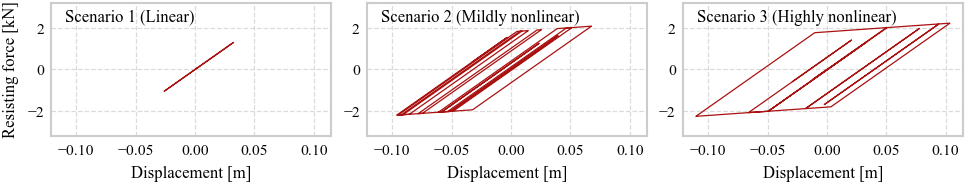

In [5]:
f=0
fig, axes = plt.subplots(1, 3, figsize=(FIG_W, FIG_H*1.3), constrained_layout=True, sharey=True, sharex=True)
axes[0].plot(response1.element_disp[f], response1.resisting_force[f]/1000, color=colors[2])
axes[0].text(0.05, 0.95, "Scenario 1 (Linear)", fontsize=8, transform=axes[0].transAxes, va="top")
axes[0].set_xlabel("Displacement [m]")
axes[0].set_ylabel("Resisting force [kN]")
axes[1].plot(response2.element_disp[f], response2.resisting_force[f]/1000, color=colors[2])
axes[1].text(0.05, 0.95, "Scenario 2 (Mildly nonlinear)", fontsize=8, transform=axes[1].transAxes, va="top")
axes[1].set_xlabel("Displacement [m]")
axes[2].plot(response3.element_disp[f], response3.resisting_force[f]/1000, color=colors[2])
axes[2].text(0.05, 0.95, "Scenario 3 (Highly nonlinear)", fontsize=8, transform=axes[2].transAxes, va="top")
axes[2].set_xlabel("Displacement [m]")
axes[0].set_ylim([-3.2, 3.2])
for ax in axes:
    ax.tick_params(labelleft=True)
plt.savefig(os.path.join(fig_dir, f'{example_name}_hysteresis_curve.pdf'))

In [6]:
time,force1,response1 = slice_data(time,force1,response1,0.01)
time = Time(start = 0, end = 10, interval = 0.0001)
time,force2,response2 = slice_data(time,force2,response2,0.01)
time = Time(start = 0, end = 10, interval = 0.0001)
time,force3,response3 = slice_data(time,force3,response3,0.01)

SNR_dB = 15
m_number = 50
m_set1 = []
m_set2 = []
m_set3 = []

std_noise1 = (np.var(response1.acc) / (10**(SNR_dB/10)))**0.5
std_noise2 = (np.var(response2.acc) / (10**(SNR_dB/10)))**0.5
std_noise3 = (np.var(response3.acc) / (10**(SNR_dB/10)))**0.5

for _ in range(m_number):
    measurement1 = add_noise(response1.acc,std_noise1)
    measurement_dm1 = np.vstack((measurement1,np.zeros((system.force_dim,time.length)),np.zeros((system.force_dim,time.length))))

    measurement2 = add_noise(response2.acc,std_noise2)
    measurement_dm2 = np.vstack((measurement2,np.zeros((system.force_dim,time.length)),np.zeros((system.force_dim,time.length))))

    measurement3 = add_noise(response3.acc,std_noise3)
    measurement_dm3 = np.vstack((measurement3,np.zeros((system.force_dim,time.length)),np.zeros((system.force_dim,time.length))))

    m_set1.append((measurement1, measurement_dm1))
    m_set2.append((measurement2, measurement_dm2))
    m_set3.append((measurement3, measurement_dm3))

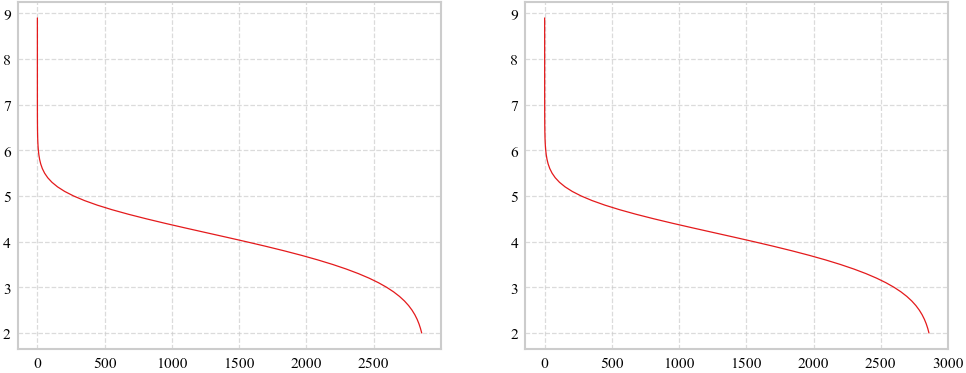

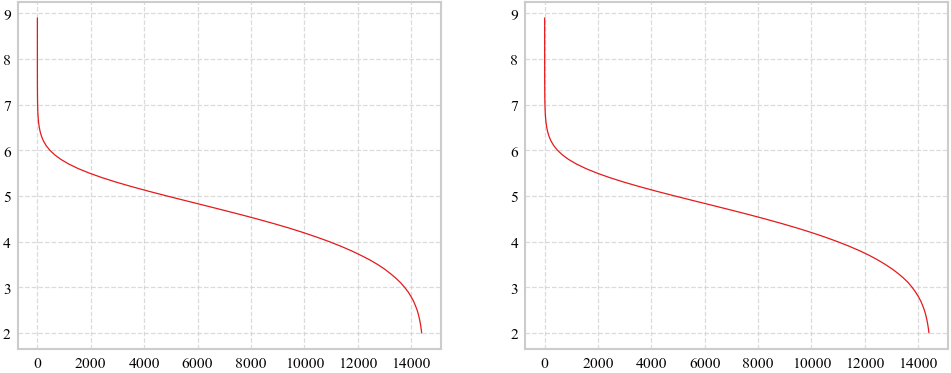

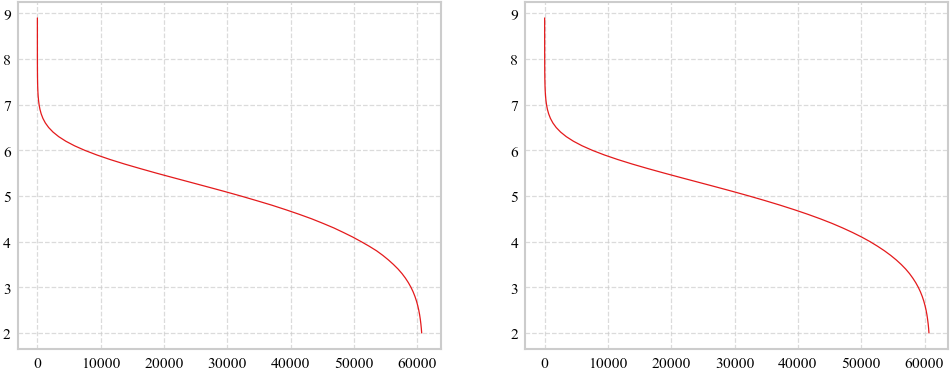

In [7]:
ssm = HysteresisSSM(system, time)
ssm_dm = HysteresisDMSSM5(system, time)
force_cov_list1 = np.arange(2,9,0.1)

cov_model = [1e-6]*(2*system.dim+system.element_dim)
cov_force = [10**0]*system.force_dim

cov_measurement1 = np.diag([std_noise1**2]*system.dim)
cov_measurement_dm1 = np.diag([std_noise1**2]*system.dim+[10**-2]*system.element_dim+[10**7]*system.force_dim)

ssm.set_covs(cov_model=cov_model, cov_measurement=cov_measurement1, cov_force=cov_force)
ssm_dm.set_covs(cov_model=cov_model, cov_measurement=cov_measurement_dm1, cov_force=cov_force)

err1 = ssm.draw_Lcurve(measurement = measurement1, initial_state_cov = np.eye(ssm.state_size)*10**-10, force_cov_list=force_cov_list1, num_cores = 32)
err_dm1 = ssm_dm.draw_Lcurve(measurement = measurement_dm1, initial_state_cov = np.eye(ssm_dm.state_size)*10**-10, force_cov_list=force_cov_list1, num_cores = 32)

cov_measurement2 = np.diag([std_noise2**2]*system.dim)
cov_measurement_dm2 = np.diag([std_noise2**2]*system.dim+[10**-2]*system.element_dim+[10**7.5]*system.force_dim)

ssm.set_covs(cov_model=cov_model, cov_measurement=cov_measurement2, cov_force=cov_force)
ssm_dm.set_covs(cov_model=cov_model, cov_measurement=cov_measurement_dm2, cov_force=cov_force)

err2 = ssm.draw_Lcurve(measurement = measurement2, initial_state_cov = np.eye(ssm.state_size)*10**-10, force_cov_list=force_cov_list1, num_cores = 32)
err_dm2 = ssm_dm.draw_Lcurve(measurement = measurement_dm2, initial_state_cov = np.eye(ssm_dm.state_size)*10**-10, force_cov_list=force_cov_list1, num_cores = 32)

cov_measurement3 = np.diag([std_noise3**2]*system.dim)
cov_measurement_dm3 = np.diag([std_noise3**2]*system.dim+[10**-2]*system.element_dim+[10**8]*system.force_dim)

ssm.set_covs(cov_model=cov_model, cov_measurement=cov_measurement3, cov_force=cov_force)
ssm_dm.set_covs(cov_model=cov_model, cov_measurement=cov_measurement_dm3, cov_force=cov_force)

err3 = ssm.draw_Lcurve(measurement = measurement3, initial_state_cov = np.eye(ssm.state_size)*10**-10, force_cov_list=force_cov_list1, num_cores = 32)
err_dm3 = ssm_dm.draw_Lcurve(measurement = measurement_dm3, initial_state_cov = np.eye(ssm_dm.state_size)*10**-10, force_cov_list=force_cov_list1, num_cores = 32)

plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.plot(err1[:,0], force_cov_list1)
plt.subplot(1,2,2)
plt.plot(err_dm1[:,0], force_cov_list1)
plt.show()
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.plot(err2[:,0], force_cov_list1)
plt.subplot(1,2,2)
plt.plot(err_dm2[:,0], force_cov_list1)
plt.show()
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.plot(err3[:,0], force_cov_list1)
plt.subplot(1,2,2)
plt.plot(err_dm3[:,0], force_cov_list1)
plt.show()

In [8]:
ssm = HysteresisSSM(system, time)
ssm_dm = HysteresisDMSSM5(system, time)

cov_force1 = [10**5.5]*system.force_dim
cov_force2 = [10**6.5]*system.force_dim
cov_force3 = [10**7]*system.force_dim

res1 = []
res2 = []
res3 = []

for ii in range(m_number):
    measurement1, measurement_dm1 = m_set1[ii]
    measurement2, measurement_dm2 = m_set2[ii]
    measurement3, measurement_dm3 = m_set3[ii]
    ssm.set_covs(cov_model=cov_model, cov_measurement=cov_measurement1, cov_force=cov_force1)
    ssm_dm.set_covs(cov_model=cov_model, cov_measurement=cov_measurement_dm1, cov_force=cov_force1)

    response_kf1, force_kf1, response_rts1, force_rts1 = ssm.kfrts(measurement1, initial_state_cov = np.eye(ssm.state_size)*10**-10)
    response_kf_dm1, force_kf_dm1, response_rts_dm1, force_rts_dm1 = ssm_dm.kfrts(measurement_dm1, initial_state_cov = np.eye(ssm_dm.state_size)*10**-10)

    ssm.set_covs(cov_model=cov_model, cov_measurement=cov_measurement2, cov_force=cov_force2)
    ssm_dm.set_covs(cov_model=cov_model, cov_measurement=cov_measurement_dm2, cov_force=cov_force2)

    response_kf2, force_kf2, response_rts2, force_rts2 = ssm.kfrts(measurement2, initial_state_cov = np.eye(ssm.state_size)*10**-10)
    response_kf_dm2, force_kf_dm2, response_rts_dm2, force_rts_dm2 = ssm_dm.kfrts(measurement_dm2, initial_state_cov = np.eye(ssm_dm.state_size)*10**-10)

    ssm.set_covs(cov_model=cov_model, cov_measurement=cov_measurement3, cov_force=cov_force3)
    ssm_dm.set_covs(cov_model=cov_model, cov_measurement=cov_measurement_dm3, cov_force=cov_force3)

    response_kf3, force_kf3, response_rts3, force_rts3 = ssm.kfrts(measurement3, initial_state_cov = np.eye(ssm.state_size)*10**-10)
    response_kf_dm3, force_kf_dm3, response_rts_dm3, force_rts_dm3 = ssm_dm.kfrts(measurement_dm3, initial_state_cov = np.eye(ssm_dm.state_size)*10**-10)

    res1.append((response_kf1, force_kf1, response_rts1, force_rts1, response_kf_dm1, force_kf_dm1, response_rts_dm1, force_rts_dm1))
    res2.append((response_kf2, force_kf2, response_rts2, force_rts2, response_kf_dm2, force_kf_dm2, response_rts_dm2, force_rts_dm2))
    res3.append((response_kf3, force_kf3, response_rts3, force_rts3, response_kf_dm3, force_kf_dm3, response_rts_dm3, force_rts_dm3))

In [9]:
def UKFUI(system, time, initial_state, initial_cov, model_cov, measurement_cov, measurement, alpha):
    state_dim = system.dim * 2 + system.element_dim
    force_dim = system.force_dim

    est_state = np.zeros((state_dim, time.length))
    est_cov = np.zeros((state_dim, state_dim, time.length))
    est_force = np.zeros((force_dim, time.length))

    state = initial_state
    cov = initial_cov
    force = np.zeros(force_dim)
    acc = compute_acc(system, state, force)

    beta = 2.0
    kappa = 0.0

    n = state_dim
    lam = alpha**2 * (n) - n
    c = n + lam

    Wm = np.full(2*n + 1, 1.0/(2*c))
    Wc = np.full(2*n + 1, 1.0/(2*c))
    Wm[0] = lam / c
    Wc[0] = lam / c + (1 - alpha**2 + beta)

    for ii in range(time.length):
        if ii % 10 == 0:
            print(f"Progress: {ii}/{time.length}", end='\r')
        evalues, evectors = np.linalg.eig(cov)
        assert (evalues >= 0).all()
        sigma_points = np.zeros((state_dim, 2*state_dim + 1))
        sigma_points[:,0] = state
        L = np.linalg.cholesky(cov)
        for j in range(n):
            sigma_points[:, j+1]     = state + np.sqrt(c) * L[:, j]
            sigma_points[:, j+1+n]   = state - np.sqrt(c) * L[:, j]
        state_pred_points, acc_pred_points = compute_response_step(system, time, sigma_points, force, acc)
        state_pred = np.sum(Wm * state_pred_points, axis=1)
        diff = state_pred_points - state_pred[:, None]
        cov_pred = diff @ np.diag(Wc) @ diff.T + model_cov
        
        Cc1 = np.atleast_2d(-inv(system.mass)@system.comp_mat.T@np.diag(system.alpha*system.element_stiff)@system.comp_mat)
        Cc2 = np.atleast_2d(-inv(system.mass)@system.comp_mat.T@np.diag((1-system.alpha)*system.element_stiff))
        Cc3 = np.atleast_2d(-inv(system.mass)@system.damping)
        Cc4 = np.atleast_2d(inv(system.mass)@system.force_influence)
        Cc = np.hstack((Cc1, Cc2, Cc3))

        force = inv(Cc4.T@Cc4)@(Cc4.T)@(measurement[:,ii] - Cc @ state_pred)

        meas_pred_points = compute_acc(system, state_pred_points, force)
        meas_pred = np.sum(Wm * meas_pred_points, axis=1)
        meas_diff = meas_pred_points - meas_pred[:, None]
        cov_meas = meas_diff @ np.diag(Wc) @ meas_diff.T + measurement_cov

        cross_diff = state_pred_points - state_pred[:, None]
        cross_cov = cross_diff @ np.diag(Wc) @ meas_diff.T
        K = cross_cov @ np.linalg.inv(cov_meas)


        state = state_pred + K @ (measurement[:,ii] - meas_pred)
        cov = cov_pred - K @ cov_meas @ K.T
        
        acc = compute_acc(system, state, force)

        est_state[:,ii] = state
        est_cov[:,:,ii] = cov
        est_force[:,ii] = force

    return est_state, est_cov, est_force

def compute_response_step(system,time,state_list,force,acc):
    state_post = np.zeros(state_list.shape)
    acc_post = np.zeros((system.dim,state_list.shape[1]))
    for ii in range(state_list.shape[1]):
        state = state_list[:,ii]

        GAMMA = 1/2
        BETA = 1/4

        A1 = 1/BETA/time.interval**2*system.mass + GAMMA/BETA/time.interval*system.damping
        A2 = 1/BETA/time.interval*system.mass + (GAMMA/BETA-1)*system.damping
        A3 = (1/2/BETA-1)*system.mass + system.damping*time.interval*(GAMMA/2/BETA-1)

        tangent_stiff_hat = system.stiff + A1
        tangent_stiff_hat_inv = inv(tangent_stiff_hat)

        MAX_ITER = 5000
        disp = state[0:system.dim].copy()
        aux = state[system.dim:system.dim+system.element_dim].copy()
        element_disp = system.comp_mat @ disp
        resisting_force = system.alpha*system.element_stiff*element_disp+(1-system.alpha)*system.element_stiff*aux
        force_hat = system.force_influence@force + A1@disp + A2 @ state[system.dim+system.element_dim:system.dim*2+system.element_dim] + A3 @ acc
        for jj in range(MAX_ITER):
            residual_force = force_hat - system.comp_mat.T @ resisting_force - A1 @ disp
            delta_disp = tangent_stiff_hat_inv @ residual_force
            disp += delta_disp
            element_disp = system.comp_mat @ disp
            delta_element_disp = element_disp - system.comp_mat @ state[0:system.dim]

            if system.model == 'BoucWen':
                delta_aux = delta_element_disp*(system.A-abs(state[system.dim:system.dim+system.element_dim])**system.n*(system.gamma+system.beta*np.sign(state[system.dim:system.dim+system.element_dim]*(system.comp_mat@state[system.dim+system.element_dim:system.dim*2+system.element_dim]))))
                aux = state[system.dim:system.dim+system.element_dim] + delta_aux
                resisting_force = system.alpha*system.element_stiff*element_disp+(1-system.alpha)*system.element_stiff*aux
            
            if (np.all(residual_force**2 < 1e-12) or
                np.all(residual_force**2 / np.maximum(np.max(np.abs(force_hat)), 1e-10)**2 < 1e-12)):
                break

        if jj == MAX_ITER-1 and np.any(np.abs(residual_force) >= 1e-10):
            print(residual_force, force_hat)
            print('Newton-Raphson did not converge')                    

        vel = GAMMA/BETA/time.interval*(disp-state[0:system.dim])+(1-GAMMA/BETA)*state[system.dim+system.element_dim:system.dim*2+system.element_dim]+time.interval*(1-GAMMA/2/BETA)*acc
        state_post[:,ii] = np.concatenate((disp, aux, vel))
        acc_post[:,ii] = compute_acc(system, state_post[:,ii], force)

    return state_post, acc_post

def compute_acc(system, state, force):
    Cc1 = np.atleast_2d(-inv(system.mass)@system.comp_mat.T@np.diag(system.alpha*system.element_stiff)@system.comp_mat)
    Cc2 = np.atleast_2d(-inv(system.mass)@system.comp_mat.T@np.diag((1-system.alpha)*system.element_stiff))
    Cc3 = np.atleast_2d(-inv(system.mass)@system.damping)
    Cc4 = np.atleast_2d(inv(system.mass)@system.force_influence)
    Cc = np.hstack((Cc1, Cc2, Cc3))
    return Cc@state + Cc4@force

In [10]:
initial_state = np.zeros(system.dim*2+system.element_dim)
initial_cov = np.eye(system.dim*2+system.element_dim)*1e-6
scale = 1.0
model_cov = np.diag([1e-6]*(system.dim*2+system.element_dim))

ukf1 = []
ukf2 = []
ukf3 = []

for ii in range(m_number):
    measurement1, measurement_dm1 = m_set1[ii]
    measurement2, measurement_dm2 = m_set2[ii]
    measurement3, measurement_dm3 = m_set3[ii]

    measurement_cov = np.diag([std_noise1**2]*system.dim)
    est_state1, est_cov1, est_force1 = UKFUI(system, time, initial_state, initial_cov, model_cov, measurement_cov, measurement1, scale)

    measurement_cov = np.diag([std_noise2**2]*system.dim)
    est_state2, est_cov2, est_force2 = UKFUI(system, time, initial_state, initial_cov, model_cov, measurement_cov, measurement2, scale)

    measurement_cov = np.diag([std_noise3**2]*system.dim)
    est_state3, est_cov3, est_force3 = UKFUI(system, time, initial_state, initial_cov, model_cov, measurement_cov, measurement3, scale)

    ukf1.append((est_state1, est_cov1, est_force1))
    ukf2.append((est_state2, est_cov2, est_force2))
    ukf3.append((est_state3, est_cov3, est_force3))

In [11]:
def rmse(true, pred):
    return np.sqrt(np.mean((true - pred)**2, axis=1)) / np.sqrt(np.mean(true**2, axis=1))

def collect_rmse(res_list, ukf_list, response_true, force_true):
    n = len(res_list)
    data = {k: np.zeros(n) for k in [
        'kf_disp', 'kf_vel', 'kf_force',
        'kf_dm_disp', 'kf_dm_vel', 'kf_dm_force',
        'rts_disp', 'rts_vel', 'rts_force',
        'rts_dm_disp', 'rts_dm_vel', 'rts_dm_force',
        'ukf_disp', 'ukf_vel', 'ukf_force',
    ]}
    for ii in range(n):
        (response_kf, force_kf, response_rts, force_rts,
         response_kf_dm, force_kf_dm, response_rts_dm, force_rts_dm) = res_list[ii]
        est_state, est_cov, est_force = ukf_list[ii]

        data['kf_disp'][ii]    = rmse(response_true.disp, response_kf.disp)[0]
        data['kf_vel'][ii]     = rmse(response_true.vel,  response_kf.vel)[0]
        data['kf_force'][ii]   = rmse(force_true.value,   force_kf.value)[0]

        data['kf_dm_disp'][ii]  = rmse(response_true.disp, response_kf_dm.disp)[0]
        data['kf_dm_vel'][ii]   = rmse(response_true.vel,  response_kf_dm.vel)[0]
        data['kf_dm_force'][ii] = rmse(force_true.value,   force_kf_dm.value)[0]

        data['rts_disp'][ii]    = rmse(response_true.disp, response_rts.disp)[0]
        data['rts_vel'][ii]     = rmse(response_true.vel,  response_rts.vel)[0]
        data['rts_force'][ii]   = rmse(force_true.value,   force_rts.value)[0]

        data['rts_dm_disp'][ii]  = rmse(response_true.disp, response_rts_dm.disp)[0]
        data['rts_dm_vel'][ii]   = rmse(response_true.vel,  response_rts_dm.vel)[0]
        data['rts_dm_force'][ii] = rmse(force_true.value,   force_rts_dm.value)[0]

        data['ukf_disp'][ii]    = rmse(response_true.disp, est_state[0:1, :])[0]
        data['ukf_vel'][ii]     = rmse(response_true.vel,  est_state[2:3, :])[0]
        data['ukf_force'][ii]   = rmse(force_true.value,   est_force)[0]
    return data

rmse_data1 = collect_rmse(res1, ukf1, response1, force1)
rmse_data2 = collect_rmse(res2, ukf2, response2, force2)
rmse_data3 = collect_rmse(res3, ukf3, response3, force3)

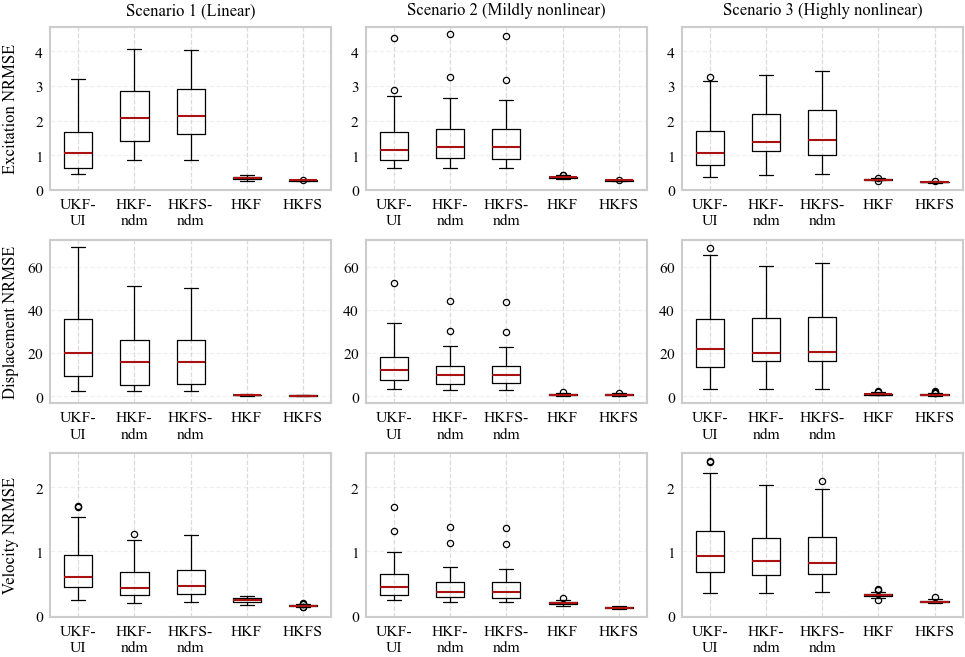

In [12]:
quantities = ['force', 'disp', 'vel']
quantity_labels = ['Excitation', 'Displacement', 'Velocity']
rmse_datas = [rmse_data1, rmse_data2, rmse_data3]
case_labels_plot = ['Scenario 1 (Linear)', 'Scenario 2 (Mildly nonlinear)', 'Scenario 3 (Highly nonlinear)']

fig, axes = plt.subplots(3, 3, figsize=(FIG_W, 3*FIG_H*1.5), constrained_layout=True, sharey="row")

for i, (qty, qty_label) in enumerate(zip(quantities, quantity_labels)):
    for j, (rmse_data, case_label) in enumerate(zip(rmse_datas, case_labels_plot)):
        ax = axes[i, j]
        data = [
            rmse_data[f"ukf_{qty}"],
            rmse_data[f"kf_{qty}"],
            rmse_data[f"rts_{qty}"],
            rmse_data[f"kf_dm_{qty}"],
            rmse_data[f"rts_dm_{qty}"],
        ]

        bp = ax.boxplot(data, labels=labels, medianprops=dict(color=colors[2]))
        for b in bp["boxes"]:   b.set_linewidth(0.6)
        for w in bp["whiskers"]: w.set_linewidth(0.6)
        for c in bp["caps"]:     c.set_linewidth(0.6)
        for fl in bp["fliers"]:
            fl.set_markeredgewidth(0.6)
            fl.set_markersize(3)

        ax.set_xticklabels(labels)
        ax.grid(True, axis="y", alpha=0.3, linestyle="--")
        ax.tick_params(labelleft=True)

        if i == 0:
            ax.set_title(case_label)
        if j == 0:
            ax.set_ylabel(qty_label + " NRMSE")

fig.align_ylabels(axes[:, 0])
plt.savefig(os.path.join(fig_dir, f"rmse_boxplot_{example_name}.pdf"), bbox_inches="tight")
plt.show()